In [ ]:
# Install required libraries (run once)

!pip install pandas numpy scikit-learn matplotlib seaborn

In [1]:
import pandas as pd
import re
import pickle

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("disaster_messages.csv")
df.head()

,text,label
0,Someone is bleeding at area,urgent
1,Water level rising I am stuck in apartment,critical
2,Medical emergency at road,urgent
3,Any updates about block,low
4,We are safe but need food at street,medium


In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['text'] = df['text'].apply(clean_text)

df.head()

,text,label
0,someone is bleeding at area,urgent
1,water level rising i am stuck in apartment,critical
2,medical emergency at road,urgent
3,any updates about block,low
4,we are safe but need food at street,medium


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [5]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [6]:
model = LogisticRegression(
    max_iter=200,
    class_weight='balanced'
)

model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [7]:
y_pred = model.predict(X_test_vec)
y_prob = model.predict_proba(X_test_vec)

In [8]:
#Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9967105263157895

Classification Report:

              precision    recall  f1-score   support

    critical       1.00      1.00      1.00        81
         low       1.00      1.00      1.00        81
      medium       1.00      0.99      0.99        71
      urgent       0.99      1.00      0.99        71

    accuracy                           1.00       304
   macro avg       1.00      1.00      1.00       304
weighted avg       1.00      1.00      1.00       304



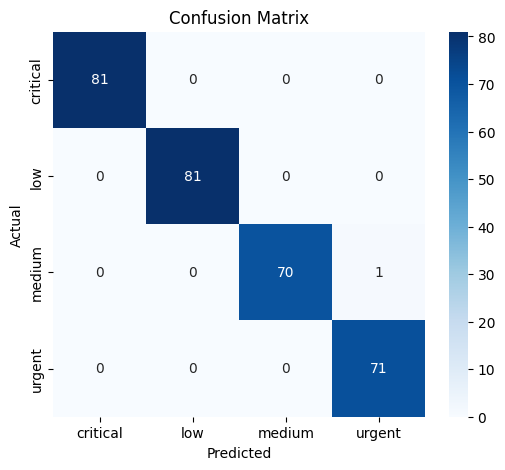

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

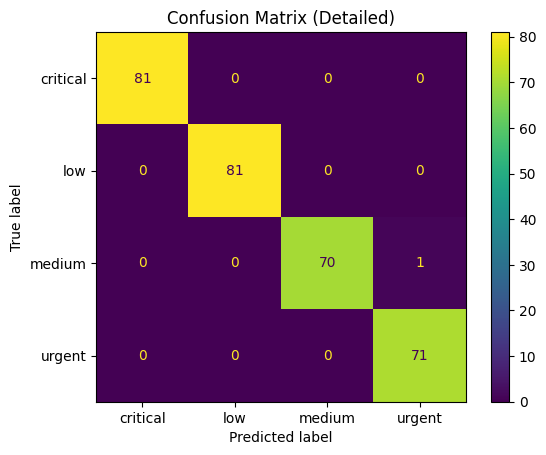

In [10]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.title("Confusion Matrix (Detailed)")
plt.show()

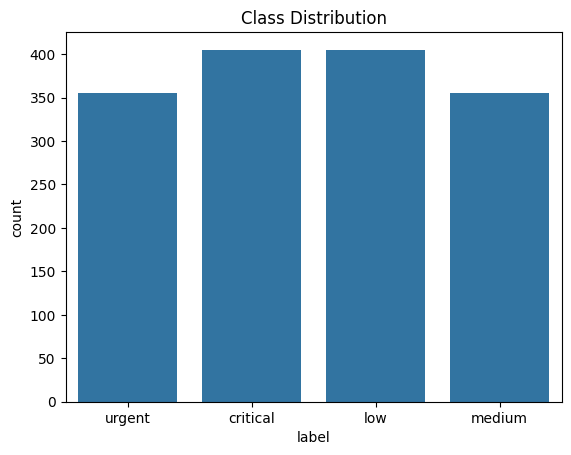

In [11]:
sns.countplot(x=df['label'])
plt.title("Class Distribution")
plt.show()

In [12]:
scores = cross_val_score(model, X_train_vec, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [1.         1.         1.         0.99588477 1.        ]
Average CV score: 0.9991769547325102


In [13]:
results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

# False predictions
errors = results[results['actual'] != results['predicted']]

errors.head(10)

,text,actual,predicted
671,water needed urgent,medium,urgent


In [14]:
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


In [15]:
test_msgs = [
    "pls hlp im stuck water rising fast",
    "need help maybe injured not sure",
    "food needed but situation okay",
    "any updates??"
]

for msg in test_msgs:
    X = vectorizer.transform([msg])
    print(msg, "->", model.predict(X)[0])

pls hlp im stuck water rising fast -> critical
need help maybe injured not sure -> urgent
food needed but situation okay -> medium
any updates?? -> low
